# Stage 2: Loyalty Classifier

**Goal of this step:** We want to predict whether each potential client in Valmontier will join the loyalty program. 

What we know is loyalty may depend on the distance to the assigned store but we cannot know that distance until we actually open a store. 

To get around this we predict loyalty for every possible client+ site pair and build a loyalty matrix. This matrix will feed directly into the demand estimation step.

>Note: Most functions are defined in the `handlers/classifier_handlers.py` file (for notebook clarity).

In [17]:
import sys
sys.path.append('handlers')
import numpy as np
import matplotlib.pyplot as plt
import handlers.classifier_handlers as ch

historic, potential, sites = ch.load_data()
print(f"Historic clients : {len(historic)} rows  |  Loyal: {historic['loyal'].sum()} ({historic['loyal'].mean():.0%})")
print(f"Potential clients: {len(potential)} rows")
print(f"Candidate sites  : {len(sites)} sites")

Historic clients : 500 rows  |  Loyal: 105 (21%)
Potential clients: 200 rows
Candidate sites  : 8 sites


## 1. Features & train/test split

We use the features that are available for both historic and potential clients: `employes`, `surface`, `firm_age`, `monthly_volume`, `purchase_staff`, and `dist_retail_point`. We drop `purchased_products` 

> `purchased_products` is in the historic data but not in the potential clients dataset, so we can't use it for prediction.

Since only 21% of historic clients are loyal, we have data unbalance that will skew the models into thinking everyone is non-loyal. We use `class_weight='balanced'` on both models to force them to actually learn the loyal class.

In [18]:
X_train, X_test, y_train, y_test = ch.split_data(historic, test_size=0.2)
print(f"Train: {len(X_train)} samples  |  Test: {len(X_test)} samples")
print(f"Loyal share — train: {y_train.mean():.0%}  |  test: {y_test.mean():.0%}")

Train: 400 samples  |  Test: 100 samples
Loyal share — train: 21%  |  test: 21%


## 2. Model training & evaluation

We train two classifiers and compare them:
- **Logistic Regression**: simplest classifier, features are standardised internally before fitting
- **Random Forest**: classifier that handles non-linear patterns between features (usually gives better results on tabular data).

We will look at the classification report and ROC curve to decide which one to use for the loyalty matrix.

In [19]:
lr, rf = ch.train_classifiers(X_train, y_train)
NAMES  = ["Logistic Regression", "Random Forest"]
MODELS = [lr, rf]

ch.evaluation_report(MODELS, NAMES, X_test, y_test)

 Logistic Regression   (ROC AUC = 0.857)
              precision    recall  f1-score   support

   Non-Loyal       0.94      0.81      0.87        79
       Loyal       0.53      0.81      0.64        21

    accuracy                           0.81       100
   macro avg       0.74      0.81      0.76       100
weighted avg       0.86      0.81      0.82       100

 Random Forest   (ROC AUC = 0.866)
              precision    recall  f1-score   support

   Non-Loyal       0.86      0.96      0.91        79
       Loyal       0.75      0.43      0.55        21

    accuracy                           0.85       100
   macro avg       0.81      0.70      0.73       100
weighted avg       0.84      0.85      0.83       100



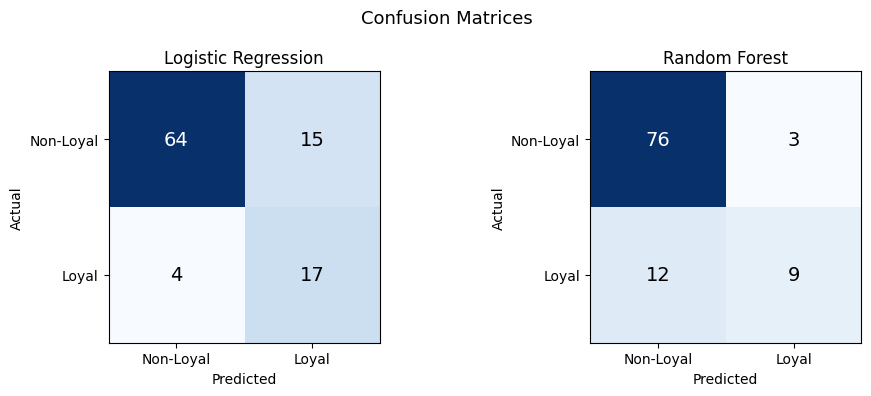

In [20]:
ch.plot_confusion_matrices(MODELS, NAMES, X_test, y_test)
plt.show()

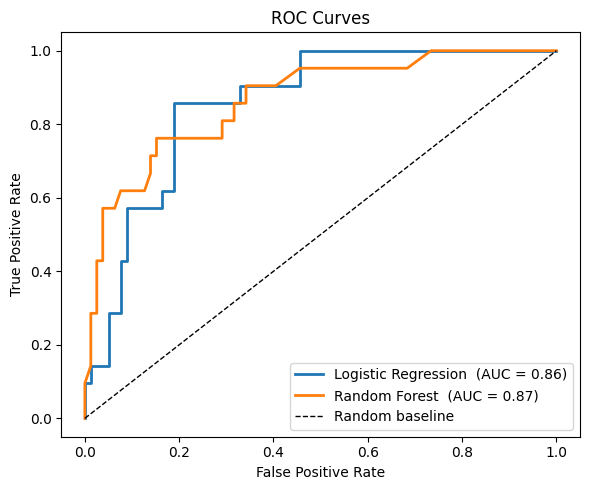

In [21]:
ch.plot_roc_curves(MODELS, NAMES, X_test, y_test)
plt.show()

## 3. Building the loyalty matrix

We take the chosen model and run it on all 200 potential clients *8 candidate sites. For each pair, we compute the Euclidean distance between the client and that site and combine it with the client's firm characteristics to get a prediction.

The output is a 200 *8 matrix of 0s and 1s  (1 meaning the client is predicted to be loyal if assigned to that site).

**Which model to choose:** Both models have a similar AUC (around 0.86), but the recall on the loyal class is very different: 
- LR catches 81% of actual loyal clients
- Random Forest only catches 43%. 

Since loyal clients buy around 72% more per week on average, missing them means we would underestimate demand for those client-site pairs. => **We should use Logistic Regression.**

In [22]:
best_model = lr  # Logistic Regression — higher recall on the loyal class (0.81 vs 0.43)

loyalty_matrix = ch.build_loyalty_matrix(best_model, potential, sites)
print(f"Loyalty matrix shape : {loyalty_matrix.shape}")
print(f"Overall predicted loyal share: {loyalty_matrix.mean():.1%}")
print()
print("Sample (first 5 clients, all 8 sites):")
print(loyalty_matrix[:5])

Loyalty matrix shape : (200, 8)
Overall predicted loyal share: 11.8%

Sample (first 5 clients, all 8 sites):
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 1 0 0 0 0 0 0]]


## 4. Predicted loyalty distribution per site

We check how many clients are predicted loyal for each candidate site. 

>Sites with more loyal clients around them will tend to attract higher and more stable demand.

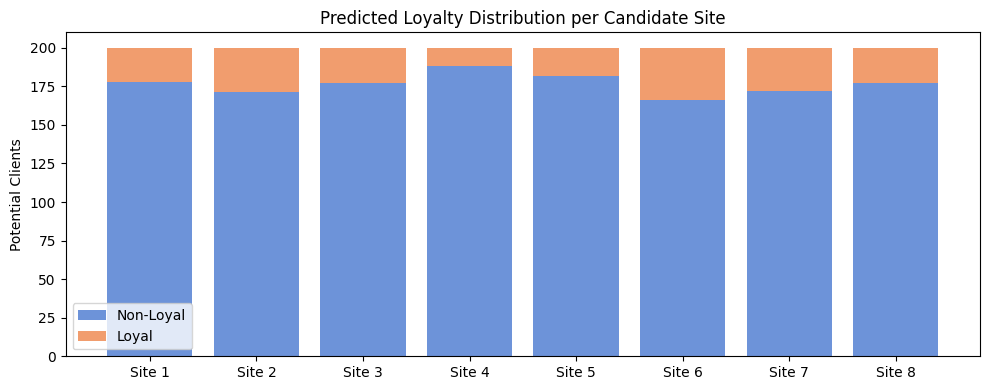

In [23]:
ch.plot_loyalty_matrix_summary(loyalty_matrix)
plt.show()

In [24]:
# Save loyalty matrix for use in the demand modelling notebook
np.save("loyalty_matrix.npy", loyalty_matrix)
print("Saved: loyalty_matrix.npy")

Saved: loyalty_matrix.npy
